# Laboratorio 3.
## Grupo 2.

### Librerías importadas.

In [30]:
from pathlib import Path
import random
import kagglehub
from PIL import Image, ImageOps
from tqdm.auto import tqdm
from PIL import Image
import random
import numpy as np
import shutil
import matplotlib.pyplot as plt

### Detalles de las imágenes y rutas.

In [ ]:
DATASET_ID = "grassknoted/asl-alphabet"
IMAGENES_POR_CLASE = 700
DIM_IMAGEN = (64, 64)
SEMILLA = 0
DIRECTORIO_SALIDA = Path.cwd() / "asl_dataset"

### Carga del conjunto de datos.

In [6]:
dataset_path = Path(kagglehub.dataset_download("grassknoted/asl-alphabet", output_dir=str(DIRECTORIO_SALIDA)))
print("Dataset descargado en:", dataset_path)

100%|██████████| 1.03G/1.03G [01:06<00:00, 16.5MB/s]

Extracting files...


Dataset descargado en: c:\Users\ricro\OneDrive\Desktop\Carrera Mate\6to Semestre\DATA SCIENCE\LABORATORIO_3\LABORATORIO_3_DS\asl_dataset


### Dirección de carpetas descargadas.

In [7]:
print("Carpeta actual:", Path.cwd())

Carpeta actual: c:\Users\ricro\OneDrive\Desktop\Carrera Mate\6to Semestre\DATA SCIENCE\LABORATORIO_3\LABORATORIO_3_DS


### Características del conjunto de entrenamiento.

In [15]:
# Ruta de entrenamiento.
train_dir = Path("asl_dataset/asl_alphabet_train/asl_alphabet_train")
cantidad_de_clases = 0

for class_dir in train_dir.iterdir():
    # Evita lo que no es carpeta.
    if not class_dir.is_dir():
        continue

    # Listado de imágenes
    images = list(class_dir.glob("*.jpg"))
    print('Hay en total:', len(images), f'de la clase{class_dir.name}')

    # Cantidad de clases
    if len(images) > 0:
        cantidad_de_clases += 1

    # Muestra aleatoria.
    sampled_images = random.sample(images, k=20)

    anchos = []
    altos = []

    for image_path in sampled_images:
        with Image.open(image_path) as image:
            ancho, alto = image.size

            anchos.append(ancho)
            altos.append(alto)

    ancho_promedio = np.mean(anchos)
    alto_promedio = np.mean(altos)

    print(f"Dimensión promedio de {class_dir.name}: " f"{ancho_promedio:.2f} x {alto_promedio:.2f}")
    print('------------------------------------------------------------------------------------------')


Hay en total: 3000 de la claseA
Dimensión promedio de A: 200.00 x 200.00
------------------------------------------------------------------------------------------
Hay en total: 3000 de la claseB
Dimensión promedio de B: 200.00 x 200.00
------------------------------------------------------------------------------------------
Hay en total: 3000 de la claseC
Dimensión promedio de C: 200.00 x 200.00
------------------------------------------------------------------------------------------
Hay en total: 3000 de la claseD
Dimensión promedio de D: 200.00 x 200.00
------------------------------------------------------------------------------------------
Hay en total: 3000 de la clasedel
Dimensión promedio de del: 200.00 x 200.00
------------------------------------------------------------------------------------------
Hay en total: 3000 de la claseE
Dimensión promedio de E: 200.00 x 200.00
------------------------------------------------------------------------------------------
Hay en total

### Cantidad de clases.

In [13]:
print('Hay en total', cantidad_de_clases, 'clases en el conjunto de entrenamiento.')

Hay en total 29 clases en el conjunto de entrenamiento.


### Cantidad de imágenes en el conjunto de prueba.

In [23]:
# Ruta de prueba.
test_dir = Path("asl_dataset/asl_alphabet_test")

for class_dir in test_dir.iterdir():
    images = list(class_dir.glob("*.jpg"))
    nombres = [str(texto).rsplit('\\', 1)[-1] for texto in images]
    print(images)

print('Hay en total', len(images), 'en el conjunto de prueba (uno por cada clase, pero falta una clase.)')
print('Clases:')
print(nombres)

[WindowsPath('asl_dataset/asl_alphabet_test/asl_alphabet_test/A_test.jpg'), WindowsPath('asl_dataset/asl_alphabet_test/asl_alphabet_test/B_test.jpg'), WindowsPath('asl_dataset/asl_alphabet_test/asl_alphabet_test/C_test.jpg'), WindowsPath('asl_dataset/asl_alphabet_test/asl_alphabet_test/D_test.jpg'), WindowsPath('asl_dataset/asl_alphabet_test/asl_alphabet_test/E_test.jpg'), WindowsPath('asl_dataset/asl_alphabet_test/asl_alphabet_test/F_test.jpg'), WindowsPath('asl_dataset/asl_alphabet_test/asl_alphabet_test/G_test.jpg'), WindowsPath('asl_dataset/asl_alphabet_test/asl_alphabet_test/H_test.jpg'), WindowsPath('asl_dataset/asl_alphabet_test/asl_alphabet_test/I_test.jpg'), WindowsPath('asl_dataset/asl_alphabet_test/asl_alphabet_test/J_test.jpg'), WindowsPath('asl_dataset/asl_alphabet_test/asl_alphabet_test/K_test.jpg'), WindowsPath('asl_dataset/asl_alphabet_test/asl_alphabet_test/L_test.jpg'), WindowsPath('asl_dataset/asl_alphabet_test/asl_alphabet_test/M_test.jpg'), WindowsPath('asl_dataset

El caracter que falta en el conjunto de prueba es del.

### Eligiendo del conjunto de entrenamiento y redimensionandolo.

In [24]:
random.seed(SEMILLA)

for class_dir in train_dir.iterdir():
    # Evita lo que no es carpeta.
    if not class_dir.is_dir():
        continue

    # Listado de imágenes
    images = list(class_dir.glob("*.jpg"))

    # Elección de 600 imágenes.
    selected_images = random.sample(images, k=min(IMAGENES_POR_CLASE, len(images)))
    selected_set = set(selected_images)

    # Eliminación de imágenes no seleccionadas.
    for image_path in images:
        if image_path not in selected_set:
            image_path.unlink()

    # Redimensionamiento a 64x64
    for image_path in selected_images:
        with Image.open(image_path) as image:
            image = image.convert("RGB")
            image = image.resize(DIM_IMAGEN, resample=Image.Resampling.LANCZOS)

            # Sobrescribe la imagen original
            image.save(image_path)

    print(f"{class_dir.name}: {len(selected_images)} imágenes conservadas")

A: 700 imágenes conservadas
B: 700 imágenes conservadas
C: 700 imágenes conservadas
D: 700 imágenes conservadas
del: 700 imágenes conservadas
E: 700 imágenes conservadas
F: 700 imágenes conservadas
G: 700 imágenes conservadas
H: 700 imágenes conservadas
I: 700 imágenes conservadas
J: 700 imágenes conservadas
K: 700 imágenes conservadas
L: 700 imágenes conservadas
M: 700 imágenes conservadas
N: 700 imágenes conservadas
nothing: 700 imágenes conservadas
O: 700 imágenes conservadas
P: 700 imágenes conservadas
Q: 700 imágenes conservadas
R: 700 imágenes conservadas
S: 700 imágenes conservadas
space: 700 imágenes conservadas
T: 700 imágenes conservadas
U: 700 imágenes conservadas
V: 700 imágenes conservadas
W: 700 imágenes conservadas
X: 700 imágenes conservadas
Y: 700 imágenes conservadas
Z: 700 imágenes conservadas


### Redimensionando en el conjunto de prueba.

In [ ]:
for class_dir in test_dir.iterdir():
    # Evita lo que no es carpeta.
    if not class_dir.is_dir():
        continue

    # Listado de imágenes
    images = list(class_dir.glob("*.jpg"))
    selected_set = set(images)

    # Redimensionamiento a 64x64
    for image_path in selected_images:
        with Image.open(image_path) as image:
            image = image.convert("RGB")
            image = image.resize(DIM_IMAGEN, resample=Image.Resampling.LANCZOS)

            # Sobrescribe la imagen original
            image.save(image_path)

### Pasando 100 imágenes por clasem, del conjunto de entrenamiento al de prueba.

In [26]:
SEMILLA = 42
MUESTRAS_POR_CLASE = 100

# Nueva carpeta plana de prueba
test_dir_new = Path("test")
test_dir_new.mkdir(parents=True, exist_ok=True)

random.seed(SEMILLA)

for class_dir in train_dir.iterdir():

    images = list(class_dir.glob("*.jpg"))
    selected_images = random.sample(images, k=MUESTRAS_POR_CLASE)

    for image_path in selected_images:
        destination = test_dir_new / image_path.name
        shutil.move(str(image_path), str(destination))

### Moviendo el conjunto de prueba.

In [27]:
for image_path in test_dir.rglob("*.jpg"):

    destination = test_dir_new / image_path.name
    shutil.move(str(image_path), str(destination))

### Agrupando todo el entrenamiento.

In [28]:
MUESTRAS_POR_CLASE = 100

# Nueva carpeta plana de prueba
train_dir_new = Path("train")
train_dir_new.mkdir(parents=True, exist_ok=True)

random.seed(SEMILLA)

for class_dir in train_dir.iterdir():

    images = list(class_dir.glob("*.jpg"))

    for image_path in images:
        destination = train_dir_new / image_path.name
        shutil.move(str(image_path), str(destination))

### Eliminando la carpeta original.

In [29]:
carpeta = Path("asl_dataset")

if carpeta.exists():
    shutil.rmtree(carpeta)
    print("Carpeta eliminada.")
else:
    print("La carpeta ya fue eliminada.")

Carpeta eliminada.


### Impresión de 5 imágenes al azar en el conjunto de prueba.

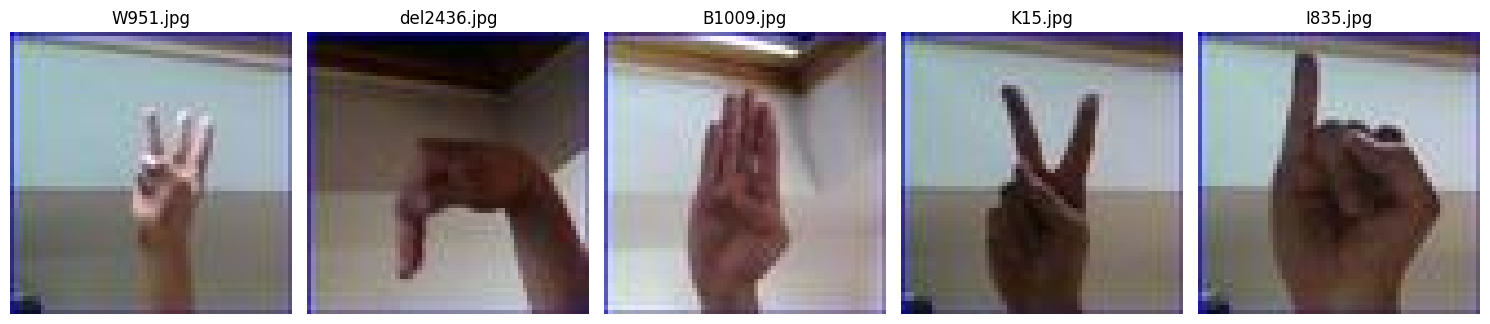

In [31]:
images = list(test_dir_new.glob("*.jpg"))
random.seed(SEMILLA)

selected_images = random.sample(images, k=min(5, len(images)))


plt.figure(figsize=(15, 4))
for i, image_path in enumerate(selected_images):
    image = Image.open(image_path)
    plt.subplot(1, len(selected_images), i + 1)
    plt.imshow(image)
    plt.title(image_path.name)
    plt.axis("off")

plt.tight_layout()
plt.show()

### Letras similares.

In [34]:
import string

random.seed(42)

# Letras desde A hasta Z
letras = string.ascii_uppercase

imagenes_seleccionadas = []
for letra in letras:
    imagenes_letra = list(test_dir_new.glob(f"{letra}_*.jpg"))
    if len(imagenes_letra) > 0:
        imagen_elegida = random.choice(imagenes_letra)
        imagenes_seleccionadas.append((letra, imagen_elegida))

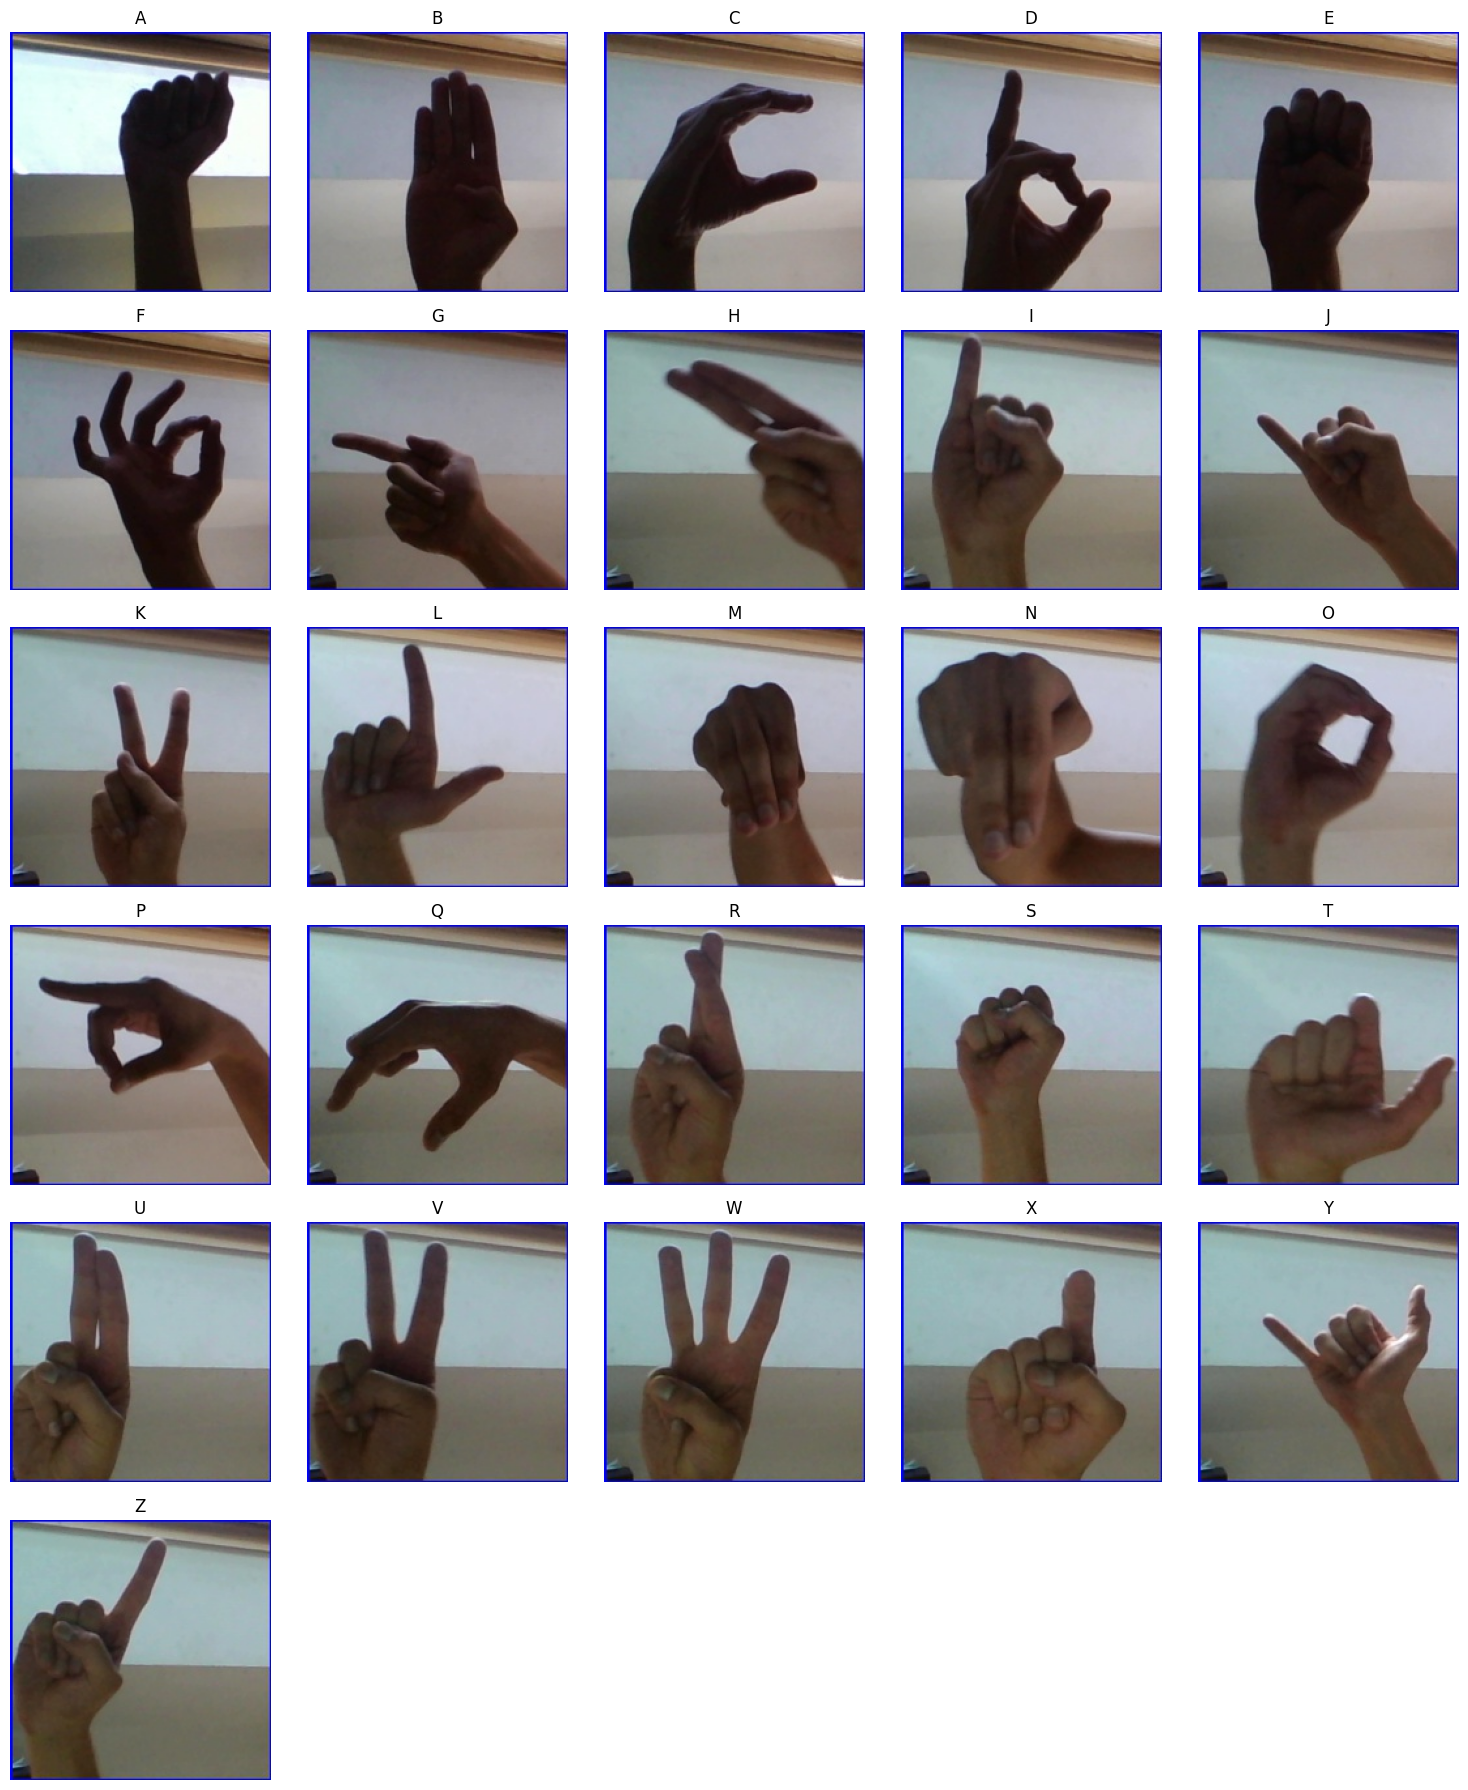

In [35]:
plt.figure(figsize=(15, 18))
for posicion, (letra, image_path) in enumerate(imagenes_seleccionadas):
    with Image.open(image_path) as image:
        plt.subplot(6, 5, posicion + 1)
        plt.imshow(image)
        plt.title(letra)
        plt.axis("off")
plt.tight_layout()
plt.show()

Las letras K y V se pueden confundir.  
Las letras G, H, J y R se pueden confundir.  
Las letras A, E y S se pueden confundir.  
Las letras U, C y Z se pueden confundir.